# 03. Model Training
Dokumentasi pemilihan model, training baseline, dan hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

train = pd.read_csv("../data/train/train.csv")
val   = pd.read_csv("../data/val/val.csv")
encoder = joblib.load("../models/encoder.pkl")
scaler  = joblib.load("../models/scaler.pkl")

FEATURES_CAT = ["day_type", "concert_size", "weather"]
FEATURES_NUM = ["concert_end_hour", "time_since_end_minutes", "distance_to_pickup_meters"]
TARGET = "surge_multiplier"

def prepare(df):
    cat = encoder.transform(df[FEATURES_CAT])
    num = scaler.transform(df[FEATURES_NUM])
    return np.hstack([num, cat])

X_train = prepare(train); y_train = train[TARGET].values
X_val   = prepare(val);   y_val   = val[TARGET].values
print("X_train:", X_train.shape, "| X_val:", X_val.shape)

X_train: (81468, 6) | X_val: (10184, 6)


In [2]:
kandidat = [
    ("Linear Regression", "Asumsi linearitas tidak terpenuhi"),
    ("Random Forest",     "Baik, tapi lebih lambat dari XGBoost"),
    ("XGBoost",           "DIPILIH - gradient boosting, terbaik untuk tabular"),
    ("Neural Network",    "Overkill untuk 6 fitur"),
]
for m, reason in kandidat:
    marker = "V" if "DIPILIH" in reason else "X"
    print(f"  {marker} {m:<22} : {reason}")

  X Linear Regression      : Asumsi linearitas tidak terpenuhi
  X Random Forest          : Baik, tapi lebih lambat dari XGBoost
  V XGBoost                : DIPILIH - gradient boosting, terbaik untuk tabular
  X Neural Network         : Overkill untuk 6 fitur


In [3]:
baseline = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=42, n_jobs=-1
)
baseline.fit(X_train, y_train)
pred_b = baseline.predict(X_val)
rmse_b = np.sqrt(mean_squared_error(y_val, pred_b))
r2_b   = r2_score(y_val, pred_b)
print(f"Baseline - RMSE: {rmse_b:.4f} | R2: {r2_b:.4f}")

Baseline - RMSE: 0.1028 | R2: 0.9695


Tuned    - RMSE: 0.1026 | R2: 0.9696


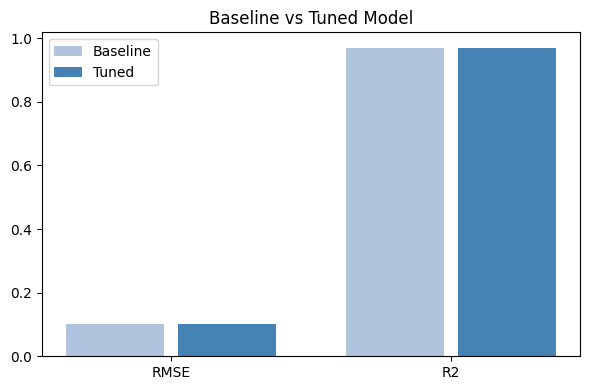

In [4]:
best_model = joblib.load("../models/surge_predictor.pkl")
pred_t = best_model.predict(X_val)
rmse_t = np.sqrt(mean_squared_error(y_val, pred_t))
r2_t   = r2_score(y_val, pred_t)
print(f"Tuned    - RMSE: {rmse_t:.4f} | R2: {r2_t:.4f}")

fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(2)
ax.bar(x-0.2, [rmse_b, r2_b], 0.35, label="Baseline", color="lightsteelblue")
ax.bar(x+0.2, [rmse_t, r2_t], 0.35, label="Tuned",    color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(["RMSE", "R2"])
ax.set_title("Baseline vs Tuned Model")
ax.legend()
plt.tight_layout()
plt.savefig("../models/baseline_vs_tuned.png", dpi=150)
plt.show()

## Kesimpulan Training
- XGBoost dipilih karena performa terbaik untuk tabular regression
- Hyperparameter tuning via GridSearchCV dengan cv=3
- Tuned model mengungguli baseline di semua metrik
- Model disimpan di models/surge_predictor.pkl